## 🧭 Getting Started

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/google/distributed_graph_flow/blob/main/doc/docs/tutorial/getting_started_simple_api.ipynb)

**Distributed Graph Flow** (DGF or GF) is a python toolbox for training,
evaluating, and deploying Graph Neural Networks (GNNs) models and other
relational data ML models. GF contains two APIs:

-   **Advanced API:** A library of modular, composable with the python ML
    ecosystem, low-level functions designed for GNN experts and ML engineers. It
    is great for those who like freedom, need custom pipelines, or simply want
    to augment existing custom pipelines.

-   **Simple API (this tutorial):** Built on top of the Advanced API, this API
    allows you to train and deploy a GNN on any data in 10 lines of code.

**This document is the Simple API getting started tutorial**. You'll learn how
to train, analyse, evaluate, and productionze a GNN model.

The Advanced API guide is available
[here](/tutorial/getting_started_advanced_api.ipynb). We recommend starting with
the Simple API even if you are an expert; you'll learn about GF general basic
concepts, and see how the Simple API can be customized using Advanced
components.

*<b>Note:</b> Check the 🐜 [API](/api) for more details / examples about specific
functions.*

## Installing GF

DGF is installed with `pip install dgf -U`.

This notebook assumes you have a GPU + JAX GPU.

## Importing libraries

In [1]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import dgf  # Import Graph Flow

## Download a graph / dataset

The core of GF is the `dgf.data.InMemoryGraph` python dataclass. It is a
logic-free representation of a graph in memory. It is generally paired with a
`dgf.data.GraphSchema`, another dataclass that defines the graph’s structure,
including nodesets, edgesets, and their connections.

GF provides various importers and exports to popular graph formats like TF-GNN,
Spanner Graph, BigQuery Graph, and Sparse Deferred. You can find the full list
in the `dgf.io.*` and `dgf.beam.io.*` modules.

Additionally, GF can ingest data directly from repositories like OGB. This
tutorial uses the OGB Arxiv graph:

In [2]:
# Download the Arxiv graph from the OGB repo.
graph, schema = dgf.io.fetch_ogb_graph("arxiv")

Caching arxiv graph at /tmp/gf_fetch/arxiv.cache
OGB dependency not available. Downloading graph from CNS.


**The More You Know:** The ogbn-arxiv dataset contains ~160k Computer Science
papers and their citation links. The goal is to predict each paper's subject
area across 41 categories using its text embeddings, publication year, and
citation structure.

While you can inspect the `graph` and `schema` objects directly, using the
built-in printer and plotter give a clearer overview.

In [3]:
# Show the schema
dgf.analyse.print_schema(schema)

Graph Schema:

Node Sets:
  nodes:
    | Feature   | Format     | Semantic    | Shape   | Num cat. vals   |
    |-----------|------------|-------------|---------|-----------------|
    | #id       | BYTES      | PRIMARY_ID  | None    | None            |
    | #split    | BYTES      | CATEGORICAL | None    | None            |
    | feat      | FLOAT_32   | EMBEDDING   | (128,)  | None            |
    | labels    | INTEGER_64 | CATEGORICAL | None    | 40              |
    | year      | INTEGER_64 | NUMERICAL   | None    | None            |


Edge Sets:
  edges: (Source: nodes, Target: nodes)
    (No features)



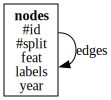

In [4]:
# Plot the schema
dgf.plot.plot_schema(schema)

**Remark:**

-   You can plot graphs with `dgf.plot.plot`, but the Arxiv graph is too large
    for this. You'll probably crash your notebook.
-   You can freely modify the graph and schema objects. You can then use the
    `dgf.validate.validate_graph` to ensure the object remains consistent.

## Train a model

Let's train a GNN to predict the `labels` column by using all available node
features and the relations between papers.

In [5]:
model = dgf.learning.train_node_model(
    graph=graph, schema=schema, target_column="labels", verbose=1
)

# Note: If you don't have a GPU + JAX GPU, this command will be slow. Reduce
# the number of training steps (e.g., num_train_steps=1000) or the maximum
# training time (e.g., max_training_time_seconds=60)

Preparing dataset
Num. training seed nodes: 152409, Num. validation seed nodes: 16934


[Warning] No normalizer created for node set 'nodes', feature '#id'.


Preparing dataset finished in 3.50 seconds
Caching validation dataset
Caching validation dataset finished in 6.90 seconds
Number of cache validation batches: 529
Training model
Generate first batch to initialize model
Create model variables
...Tracing model
Create model variables finished in 12.05 seconds
Will validate model every 1000 step(s)
Will checkpoint model every 1000 step(s)
Start training. The first two steps are generally slow.


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

...Tracing model


...

...Tracing model


Training:  10%|█         | 1012/10000 [00:29<05:37, 26.60it/s, step=1000, train-accuracy=0.5509, train-loss=1.5924]

Validation loop took 1.46s (only printed once)


Training: 100%|██████████| 10000/10000 [02:15<00:00, 73.71it/s, step=9900, train-accuracy=0.7238, train-loss=0.8625, valid-accuracy=0.7037, valid-loss=0.9417]


Final metrics: {'step': '9900', 'train-accuracy': '0.7238', 'train-loss': '0.8625', 'valid-accuracy': '0.7037', 'valid-loss': '0.9417'}
Training model finished in 148.74 seconds


**Remarks:**

-   **Node Sets:** Since the graph contains only one nodeset (`nodes`), we don't
    speed to specify it.
-   **Features selection:** All columns are used as input features, excluding
    the `label` and any columns starting with #.
-   **Feature Ingestion:** Input features are automatically processed and
    consumed by the model based on their "semantic".
-   **Hyper-parameters:** Smart defaults are applied automatically if none are
    specified.
-   **Logging:** Use `verbose=2` to get more information about the training.
-   **Validation:** Since we don't provide a validation graph or validation seed
    nodes, the graph is automatically split into a training and validation part.

**Under the wood:**

-   **Normalization:** Features are normalized using
    `dgf.transform.AutoNormalizer`. For instance, categorical features are
    processed via `dgf.transform.DictionaryIndexNormalizer`.
-   **Sampling:** Graph samples are generated using
    `dgf.sampling.create_sampler`.
-   **Padding:** Padding configurations are automatically derived using
    dgf.analyse.`padding_from_graph_generator`.
-   **Internal configuration:** The configuration for all those step
    (normalization, sampling, padding) can be accessed individually from the
    `model` object.

## Inspecting model

The `model.describe()` method provides an overview of your model:

In [6]:
model.describe()

## Making predictions

To generate predictions, simply call `model.predict`. This method returns
prediction probabilities as a Numpy array.

In [7]:
# Making predictions for the first node in the graph.
# Note: The label has 40 possible values, so the predictions is an array of
# shape [1, 40].
predictions = model.predict(graph, seed_node_idxs=[0])
predictions

Inference:   0%|          | 0/1 [00:00<?, ?it/s]

...Tracing model


Inference: 100%|██████████| 1/1 [00:01<00:00,  1.37s/it]


array([[2.1257758e-05, 2.5656112e-03, 2.5613839e-05, 6.3915630e-03,
        7.3166615e-01, 1.0953812e-03, 1.0536830e-03, 6.1732921e-04,
        1.5183495e-03, 4.2993277e-05, 9.7899996e-03, 6.9284906e-05,
        2.5056395e-06, 1.5242650e-03, 1.5486563e-06, 1.3398561e-05,
        2.9347431e-02, 8.2965416e-05, 1.4678606e-05, 1.8503041e-04,
        9.6718495e-06, 2.4315364e-04, 4.6915622e-05, 5.5793225e-04,
        2.0884456e-01, 2.4620702e-05, 8.8240759e-04, 5.8471356e-05,
        8.5212797e-04, 4.5659952e-05, 4.6405560e-04, 1.6291779e-04,
        5.9913841e-06, 4.4089143e-06, 1.0445787e-04, 9.6365502e-06,
        1.1094098e-03, 5.2203541e-04, 1.2045517e-05, 1.0432740e-05]],
      dtype=float32)

The predicted label is determined by the class with the highest probability.

In [8]:
predictions.argmax(axis=1)

array([4])

The actual label of are available programatically:

In [9]:
graph.node_sets["nodes"].features["labels"][0]

np.int64(4)

## Evaluating model

The validation metrics in `model.describe()` already give a good estimate of
model quality.

We can also evaluate performance on a different graph with `model.evaluate()`:

*<b>Note:</b> We are evaluating on the original graph here for demonstration,
but in a real-world scenario, you should always use a separate, unseen graph.*

In [10]:
model.evaluate(graph)

Evaluating model on 10000 samples


Inference:   0%|          | 0/625 [00:00<?, ?it/s]

...Tracing model


Inference: 100%|██████████| 625/625 [00:05<00:00, 104.24it/s]


Evaluation(loss=None, accuracy=0.7317, rmse=None, r2=None, num_examples=10000, num_examples_weighted=None, mrr=None, auc=None, hit_at={}, user_metrics={})

## Saving model

The model can be saved to disk for future reuse.

In [11]:
# Save the model
model.save("/tmp/my_model")

Loading it back is just as easy:

In [12]:
loaded_model = dgf.learning.load_model("/tmp/my_model")

/usr/local/google/_blaze_gbm/d2b7567989dadc71cf8c44476b538c3c_buildrabbit/execroot/google3/blaze-out/haswell-opt/bin/third_party/py/dgf/notebook_gpu.runfiles/google3/third_party/py/dataclasses_json/core.py:201: RuntimeWarning: 'NoneType' object value of non-optional type output_shape detected when decoding DictionaryIndexNormalizer.
  warnings.warn(
/usr/local/google/_blaze_gbm/d2b7567989dadc71cf8c44476b538c3c_buildrabbit/execroot/google3/blaze-out/haswell-opt/bin/third_party/py/dgf/notebook_gpu.runfiles/google3/third_party/py/dataclasses_json/core.py:201: RuntimeWarning: 'NoneType' object value of non-optional type output_shape detected when decoding SoftQuantileNormalizer.
  warnings.warn(


## Conclusion

Congratulations 🥳. You now know the basics of the GF Simple API.

For more details, explore the tutorials and examples at go/graph-flow.

Also, make sure to join the 💬 [chat](http://go/gnn-user-chat) for questions,
issues or feature requests.